# 01: Audio Loading and Exploration

This notebook walks through loading the MIMII fan dataset and extracting audio features using librosa.

## Setup: Import libraries and initialize the loader

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display

# Add src to path so we can import our modules
sys.path.insert(0, 'C:/Users/Letizia/Documents/sound-anomaly-detection/src')
from audio_loader import AudioLoader

print("✓ All imports successful!")

✓ All imports successful!


## Initialize the AudioLoader

This object handles all audio loading and MFCC feature extraction.

In [2]:
# Initialize loader
loader = AudioLoader(
    data_root="C:/Users/Letizia/Documents/sound-anomaly-detection/data",  # Path to data folder
    sr=16000,            # Sampling rate: 16 kHz (MIMII standard)
    n_mfcc=13            # Number of MFCC coefficients
)

print("AudioLoader ready!")

✓ AudioLoader initialized
  - Data root: C:\Users\Letizia\Documents\sound-anomaly-detection\data
  - Machine type: fan
  - Sampling rate: 16000 Hz
  - MFCC coefficients: 13
AudioLoader ready!


## Explore available conditions and machine IDs

In [3]:
# List all noise conditions
conditions = loader.list_available_conditions()
print(f"Available noise conditions: {conditions}")

# List machine IDs for each condition
for condition in conditions:
    machine_ids = loader.list_machine_ids(condition)
    print(f"  {condition}: {machine_ids}")

Available noise conditions: ['-6_dB', '0_dB', '6_dB']
  -6_dB: ['id_00', 'id_02', 'id_04', 'id_06']
  0_dB: ['id_00', 'id_02', 'id_04', 'id_06']
  6_dB: ['id_00', 'id_02', 'id_04', 'id_06']


## Example 1: Load a single audio file

Understand what librosa gives you: raw audio waveform and MFCC features.

In [4]:
from pathlib import Path

# Find the first normal audio file
normal_dir = Path("C:/Users/Letizia/Documents/sound-anomaly-detection/data/0_dB_fan/fan/id_00/normal")
wav_files = sorted(normal_dir.glob("*.wav"))

if wav_files:
    example_file = str(wav_files[0])
    print(f"Loading: {example_file}\n")
    
    # Load the audio
    y, sr = loader.load_audio_file(example_file)
    
    # Print audio info
    print(f"Audio waveform:")
    print(f"  Shape: {y.shape}")
    print(f"  Data type: {y.dtype}")
    print(f"  Duration: {len(y) / sr:.2f} seconds")
    print(f"  Min value: {y.min():.4f}")
    print(f"  Max value: {y.max():.4f}")
    print(f"  Mean value: {y.mean():.4f}")
    print(f"  Sampling rate: {sr} Hz")
else:
    print("No WAV files found. Check your data path.")

Loading: C:\Users\Letizia\Documents\sound-anomaly-detection\data\0_dB_fan\fan\id_00\normal\00000000.wav

Audio waveform:
  Shape: (160000,)
  Data type: float32
  Duration: 10.00 seconds
  Min value: -0.0257
  Max value: 0.0247
  Mean value: -0.0000
  Sampling rate: 16000 Hz


## Visualize the audio waveform

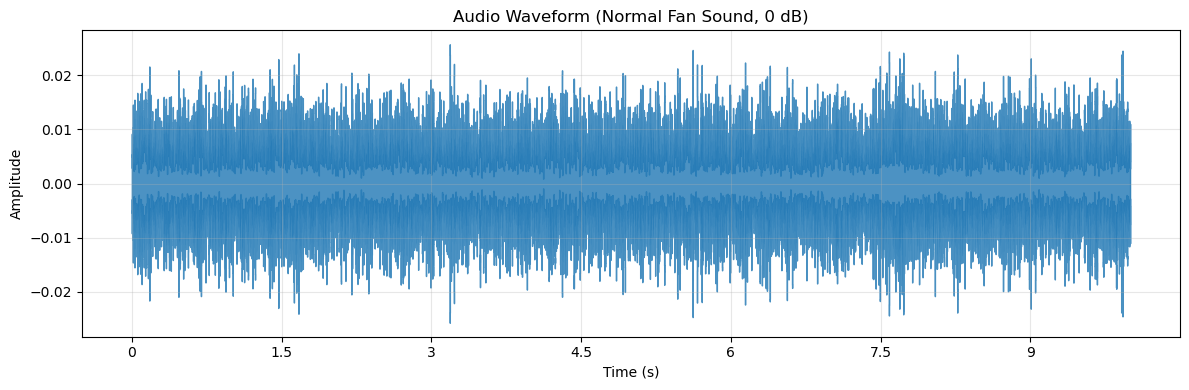

In [5]:
plt.figure(figsize=(12, 4))
librosa.display.waveshow(y, sr=sr, alpha=0.8)
plt.title(f"Audio Waveform (Normal Fan Sound, 0 dB)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Extract MFCC features

In [6]:
# Extract MFCC
mfcc = loader.extract_mfcc(y)

print(f"MFCC feature matrix:")
print(f"  Shape: {mfcc.shape}")
print(f"  - Coefficients: {mfcc.shape[0]} (13 MFCC + 1 energy is typical)")
print(f"  - Time frames: {mfcc.shape[1]} (changes with audio length)")
print(f"  - Total features if flattened: {mfcc.shape[0] * mfcc.shape[1]}")
print(f"\nFirst 5 MFCC coefficients (time frame 0):")
print(mfcc[:5, 0])

MFCC feature matrix:
  Shape: (13, 313)
  - Coefficients: 13 (13 MFCC + 1 energy is typical)
  - Time frames: 313 (changes with audio length)
  - Total features if flattened: 4069

First 5 MFCC coefficients (time frame 0):
[-4.1419162e+02  1.2811496e+02  3.1766048e-01  2.5060169e+01
  5.6321068e+00]


## Visualize MFCC spectrogram

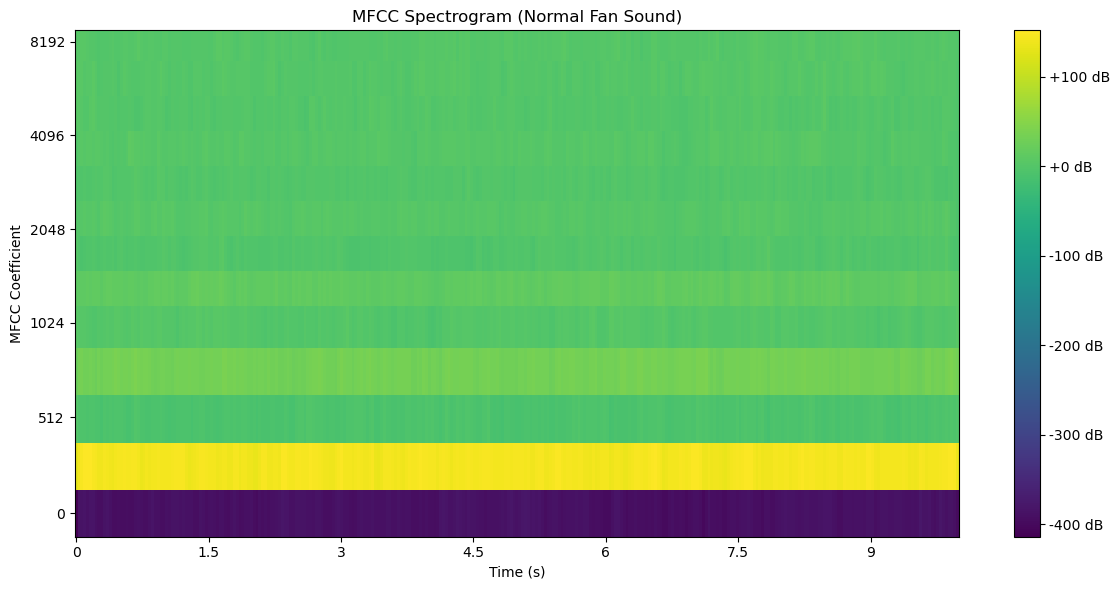

In [9]:
plt.figure(figsize=(12, 6))
img = librosa.display.specshow(
    mfcc,
    sr=sr,
    hop_length=512,
    x_axis='time',
    y_axis='mel',       #fixed 'mel_frequency', wrong name
    cmap='viridis'
)
plt.colorbar(img, format='%+2.0f dB')
plt.title("MFCC Spectrogram (Normal Fan Sound)")
plt.ylabel("MFCC Coefficient")
plt.xlabel("Time (s)")
plt.tight_layout()
plt.show()

## Aggregate MFCC to fixed-size feature vectors

For ML models like Isolation Forest, we need fixed-size feature vectors. We can aggregate across time using mean, std, delta, etc.

In [14]:
# Different aggregation methods
mfcc_mean = loader.aggregate_mfcc(mfcc, method='mean')
mfcc_std = loader.aggregate_mfcc(mfcc, method='std')
mfcc_delta = loader.aggregate_mfcc(mfcc, method='delta')

print(f"Aggregated MFCC shapes:")
print(f"  Mean:  {mfcc_mean.shape}  - Average MFCC across time")
print(f"  Std:   {mfcc_std.shape}   - Std dev of MFCC across time")
print(f"  Delta: {mfcc_delta.shape} - Mean MFCC + mean delta features")

print(f"\nMean MFCC values:")
print(mfcc_mean)

Aggregated MFCC shapes:
  Mean:  (13,)  - Average MFCC across time
  Std:   (13,)   - Std dev of MFCC across time
  Delta: (26,) - Mean MFCC + mean delta features

Mean MFCC values:
[-3.9006485e+02  1.4268546e+02 -8.0893488e+00  3.2070496e+01
 -1.0225491e-02  1.3652123e+01 -2.9653831e+00  2.5082083e+00
 -1.9032534e+00  2.1095543e+00 -4.9792612e-01  1.2809337e+00
  1.2096550e+00]


## Load all clips from a directory

In [7]:
# Load all normal sounds from id_00 at 0 dB
normal_dir = "../data/0_dB_fan/fan/id_00/normal"

print(f"Loading all clips from: {normal_dir}\n")

features, filenames = loader.load_all_clips_from_directory(
    normal_dir,
    aggregate_method='mean'
)

print(f"\nLoaded {len(features)} audio clips")
print(f"Feature vector shape: {features[0].shape}")
print(f"\nFirst 5 filenames:")
for fn in filenames[:5]:
    print(f"  - {fn}")

Loading all clips from: ../data/0_dB_fan/fan/id_00/normal


Loaded 1011 audio clips
Feature vector shape: (13,)

First 5 filenames:
  - 00000000.wav
  - 00000001.wav
  - 00000002.wav
  - 00000003.wav
  - 00000004.wav


## Convert features to numpy array for analysis

In [12]:
# Convert list to numpy array for easier manipulation
features_array = np.array(features)

print(f"Features array shape: {features_array.shape}")
print(f"  - Samples: {features_array.shape[0]}")
print(f"  - Features per sample: {features_array.shape[1]}")

# Basic statistics
print(f"\nFeature statistics (across all {len(features)} clips):")
print(f"  Mean: {features_array.mean(axis=0)[:5]}...")  # First 5 coefficients
print(f"  Std:  {features_array.std(axis=0)[:5]}...")
print(f"  Min:  {features_array.min(axis=0)[:5]}...")
print(f"  Max:  {features_array.max(axis=0)[:5]}...")

Features array shape: (1011, 13)
  - Samples: 1011
  - Features per sample: 13

Feature statistics (across all 1011 clips):
  Mean: [-381.54504    124.5021       0.9504527   22.637854     2.2159836]...
  Std:  [19.31646  17.17545   9.160481  9.491762  3.736365]...
  Min:  [-432.60333     50.54461    -41.932083     2.9812553  -12.171286 ]...
  Max:  [-321.61182   161.82898    32.727238   43.783104   13.380296]...


## Load full condition dataset (all machine IDs, both normal and anomalous)

In [13]:
# Load 0 dB condition with training machines (id_00, id_02) and test machine (id_04)
data_0db = loader.load_condition_dataset(
    condition='0_dB_fan',
    machine_ids=['id_00', 'id_02', 'id_04'],
    aggregate_method='mean'
)

print(f"\nDataset loaded successfully!")
print(f"Condition: {data_0db['condition']}")


Loading condition: 0_dB_fan
  Loading id_00 normal sounds... ✓ 1011 clips
  Loading id_00 abnormal sounds... ✓ 407 clips
  Loading id_02 normal sounds... ✓ 1016 clips
  Loading id_02 abnormal sounds... ✓ 359 clips
  Loading id_04 normal sounds... ✓ 1033 clips
  Loading id_04 abnormal sounds... ✓ 348 clips

Dataset loaded successfully!
Condition: 0_dB_fan


## Analyze dataset composition

In [17]:
print("Dataset composition:\n")

for machine_id in ['id_00', 'id_02', 'id_04']:
    n_normal = len(data_0db['machine_ids'][machine_id]['normal']['features'])
    n_abnormal = len(data_0db['machine_ids'][machine_id]['abnormal']['features'])
    total = n_normal + n_abnormal
    
    print(f"{machine_id}:")
    print(f"  Normal:    {n_normal:4d} clips")
    print(f"  Anomalous: {n_abnormal:4d} clips")
    print(f"  Total:     {total:4d} clips")
    print()

Dataset composition:

id_00:
  Normal:    1011 clips
  Anomalous:  407 clips
  Total:     1418 clips

id_02:
  Normal:    1016 clips
  Anomalous:  359 clips
  Total:     1375 clips

id_04:
  Normal:    1033 clips
  Anomalous:  348 clips
  Total:     1381 clips



## Extract training and test sets

Prepare data for Isolation Forest (Phase 4 of the experiment).

In [19]:
# Training set: normal sounds from id_00 and id_02
train_features_00 = np.array(data_0db['machine_ids']['id_00']['normal']['features'])
train_features_02 = np.array(data_0db['machine_ids']['id_02']['normal']['features'])

# Combine training data
X_train = np.vstack([train_features_00, train_features_02])

print(f"Training set (normal sounds from id_00 + id_02):")
print(f"  Shape: {X_train.shape}")
print(f"  Samples: {X_train.shape[0]}")
print(f"  Features: {X_train.shape[1]}")

# Test set: normal and anomalous from id_04 (unseen machine)
test_normal = np.array(data_0db['machine_ids']['id_04']['normal']['features'])
test_abnormal = np.array(data_0db['machine_ids']['id_04']['abnormal']['features'])

# Combine test data and create labels
X_test = np.vstack([test_normal, test_abnormal])
y_test = np.concatenate([
    np.zeros(len(test_normal)),      # Normal = 0
    np.ones(len(test_abnormal))     # Anomalous = 1
])

print(f"\nTest set (normal + abnormal from id_04, unseen machine):")
print(f"  Shape: {X_test.shape}")
print(f"  Normal samples:    {np.sum(y_test == 0)}")
print(f"  Abnormal samples: {np.sum(y_test == 1)}")

Training set (normal sounds from id_00 + id_02):
  Shape: (2027, 13)
  Samples: 2027
  Features: 13

Test set (normal + abnormal from id_04, unseen machine):
  Shape: (1381, 13)
  Normal samples:    1033
  Abnormal samples: 348


## Save datasets for later use

Save these feature sets so we can use them in the preprocessing and experiment phases.

In [20]:
# Create results directory if it doesn't exist
import os
results_dir = "../results"
os.makedirs(results_dir, exist_ok=True)

# Save training and test data
np.save(f"{results_dir}/X_train_0db.npy", X_train)
np.save(f"{results_dir}/X_test_0db.npy", X_test)
np.save(f"{results_dir}/y_test_0db.npy", y_test)

print(f"✓ Saved datasets to {results_dir}:")
print(f"  - X_train_0db.npy  (shape: {X_train.shape})")
print(f"  - X_test_0db.npy   (shape: {X_test.shape})")
print(f"  - y_test_0db.npy   (shape: {y_test.shape})")

✓ Saved datasets to ../results:
  - X_train_0db.npy  (shape: (2027, 13))
  - X_test_0db.npy   (shape: (1381, 13))
  - y_test_0db.npy   (shape: (1381,))


## Summary

You've learned:
1. ✓ How to load audio files with librosa at 16 kHz
2. ✓ How to extract MFCC features from audio
3. ✓ How to visualize waveforms and spectrograms
4. ✓ How to aggregate MFCC across time for fixed-size feature vectors
5. ✓ How to batch load all clips from a directory
6. ✓ How to structure training and test sets for the domain shift experiment

**Next steps:**
- Implement preprocessing modifications (Phases 3)
- Train Isolation Forest on baseline (Phase 4)
- Train and compare modified pipeline (Phases 5-6)